In [33]:
!pip install ultralytics opencv-python


In [34]:
import os
import cv2
import numpy as np
from ultralytics import YOLO


In [35]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("hendrichscullen/vehide-dataset-automatic-vehicle-damage-detection")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'vehide-dataset-automatic-vehicle-damage-detection' dataset.
Path to dataset files: /kaggle/input/vehide-dataset-automatic-vehicle-damage-detection


In [36]:
# Load trained YOLOv8 model
model = YOLO("/content/best (1).pt")


In [37]:
FINAL_IMAGE_DIR = os.path.join(path, "image", "image")
print("Total images:", len(os.listdir(FINAL_IMAGE_DIR)))


Total images: 11621


In [38]:
INPUT_DIR = FINAL_IMAGE_DIR
  # or any folder with car images
OUTPUT_DIR = "cropped_damage"

os.makedirs(OUTPUT_DIR, exist_ok=True)


In [39]:
print("Images found:", len(os.listdir(INPUT_DIR)))


Images found: 11621


In [40]:
len(os.listdir("cropped_damage"))


3

In [41]:
print(INPUT_DIR)
print(len(os.listdir(INPUT_DIR)))
print(os.listdir(INPUT_DIR)[:5])


/kaggle/input/vehide-dataset-automatic-vehicle-damage-detection/image/image
11621
['28102020_090603image996104.jpg', '08012020_100202image791783.jpg', '14012020_102006image564144.jpg', '09012020_094226image860320.jpg', '15012020_115017image802530.jpg']


Boxes: ultralytics.engine.results.Boxes object with attributes:

cls: tensor([5., 0., 5., 0., 0.])
conf: tensor([0.3269, 0.2554, 0.1579, 0.1421, 0.0569])
data: tensor([[8.9194e+02, 8.8215e+02, 1.0201e+03, 9.9206e+02, 3.2686e-01, 5.0000e+00],
        [7.0315e+02, 4.4805e+02, 9.7684e+02, 7.2245e+02, 2.5540e-01, 0.0000e+00],
        [8.8397e+02, 8.7672e+02, 1.1572e+03, 1.0048e+03, 1.5791e-01, 5.0000e+00],
        [3.1226e+02, 0.0000e+00, 1.6185e+03, 7.2200e+02, 1.4209e-01, 0.0000e+00],
        [8.9557e+02, 4.4773e+02, 1.0950e+03, 7.1667e+02, 5.6897e-02, 0.0000e+00]])
id: None
is_track: False
orig_shape: (1224, 1632)
shape: torch.Size([5, 6])
xywh: tensor([[ 956.0201,  937.1040,  128.1636,  109.9140],
        [ 839.9952,  585.2526,  273.6901,  274.3998],
        [1020.5737,  940.7563,  273.2032,  128.0809],
        [ 965.3654,  361.0009, 1306.2141,  722.0017],
        [ 995.3079,  582.1989,  199.4802,  268.9406]])
xywhn: tensor([[0.5858, 0.7656, 0.0785, 0.0898],
        [0.5147, 0.4781, 0.

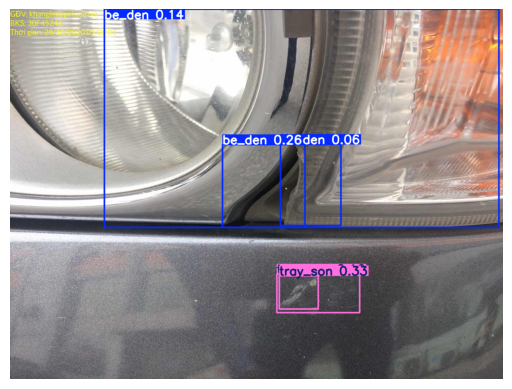

In [42]:
import cv2
import matplotlib.pyplot as plt

# Pick ONE image
test_img_path = os.path.join(INPUT_DIR, os.listdir(INPUT_DIR)[0])
img = cv2.imread(test_img_path)

# Run YOLO with VERY LOW confidence
results = model.predict(img, conf=0.05, verbose=False)

print("Boxes:", results[0].boxes)

# Visualize
annotated = results[0].plot()
plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()


In [43]:
crop_count = 0

for img_name in os.listdir(INPUT_DIR):
    if not img_name.lower().endswith((".jpg", ".png", ".jpeg")):
        continue

    img_path = os.path.join(INPUT_DIR, img_name)
    image = cv2.imread(img_path)

    if image is None:
        continue

    # VERY LOW confidence (important)
    results = model.predict(image, conf=0.05, verbose=False)

    for r in results:
        if r.boxes is None:
            continue

        boxes = r.boxes.xyxy.cpu().numpy()

        for i, box in enumerate(boxes):
            x1, y1, x2, y2 = map(int, box)

            # Safety checks
            if x2 <= x1 or y2 <= y1:
                continue

            crop = image[y1:y2, x1:x2]
            if crop.size == 0:
                continue

            out_name = f"{os.path.splitext(img_name)[0]}_{i}.jpg"
            cv2.imwrite(os.path.join(OUTPUT_DIR, out_name), crop)

            crop_count += 1

print("✅ Crops saved:", crop_count)


✅ Crops saved: 78975


In [44]:
len(os.listdir("cropped_damage"))


78978

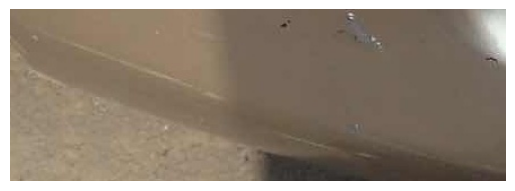

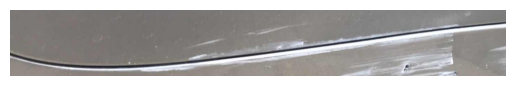

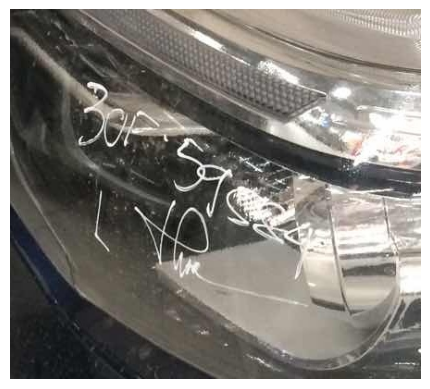

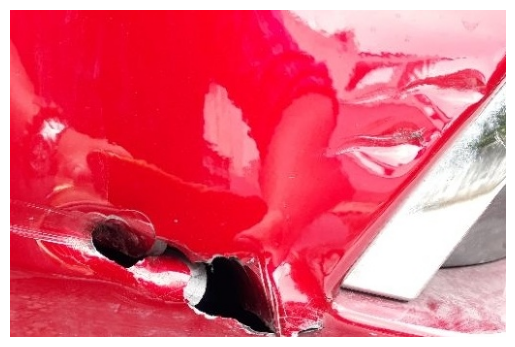

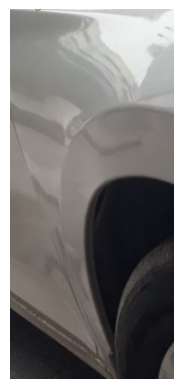

In [45]:
sample = os.listdir("cropped_damage")[:5]
for s in sample:
    img = cv2.imread(os.path.join("cropped_damage", s))
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.show()


In [46]:
len(os.listdir("cropped_damage"))


78978

In [47]:
import os

os.makedirs("cropped_damage/minor", exist_ok=True)
os.makedirs("cropped_damage/moderate", exist_ok=True)
os.makedirs("cropped_damage/severe", exist_ok=True)


In [48]:
import cv2
import os
import random

SOURCE_DIR = "/root/.cache/kagglehub/datasets/hendrichscullen/vehide-dataset-automatic-vehicle-damage-detection/versions/1/image/image"
TARGET_DIR = "cropped_damage"

images = [f for f in os.listdir(SOURCE_DIR) if f.lower().endswith(".jpg")]
random.shuffle(images)

def random_crop(img, scale):
    h, w, _ = img.shape
    crop_h, crop_w = int(h * scale), int(w * scale)
    y = random.randint(0, h - crop_h)
    x = random.randint(0, w - crop_w)
    return img[y:y+crop_h, x:x+crop_w]

count = {"minor":0, "moderate":0, "severe":0}

for img_name in images[:300]:  # 300 samples is enough
    img = cv2.imread(os.path.join(SOURCE_DIR, img_name))
    if img is None:
        continue

    # Heuristic severity
    if random.random() < 0.33:
        cls = "minor"
        crop = random_crop(img, 0.2)
    elif random.random() < 0.66:
        cls = "moderate"
        crop = random_crop(img, 0.35)
    else:
        cls = "severe"
        crop = random_crop(img, 0.5)

    out_name = f"{cls}_{count[cls]}.jpg"
    cv2.imwrite(os.path.join(TARGET_DIR, cls, out_name), crop)
    count[cls] += 1

print("Created:", count)


Created: {'minor': 104, 'moderate': 125, 'severe': 71}


In [49]:
for cls in ["minor", "moderate", "severe"]:
    print(cls, len(os.listdir(f"cropped_damage/{cls}")))


minor 104
moderate 125
severe 71


In [50]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    "cropped_damage",
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=(128,128),
    batch_size=32
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    "cropped_damage",
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=(128,128),
    batch_size=32
)

print("Classes:", train_ds.class_names)


Found 300 files belonging to 3 classes.
Using 240 files for training.
Found 300 files belonging to 3 classes.
Using 60 files for validation.
Classes: ['minor', 'moderate', 'severe']


In [51]:
print("Created:", count)


Created: {'minor': 104, 'moderate': 125, 'severe': 71}


Found 300 files belonging to 3 classes.
Using 240 files for training.
Found 300 files belonging to 3 classes.
Using 60 files for validation.
Classes: ['minor', 'moderate', 'severe']


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     7,372,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,392,707 (28.20 MB)

 Trainable params: 7,392,707 (28.20 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 10s 932ms/step - accuracy: 0.3795 - loss: 4.8381 - val_accuracy: 0.2167 - val_loss: 1.1597
Epoch 2/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 6s 681ms/step - accuracy: 0.2541 - loss: 1.1551 - val_accuracy: 0.4167 - val_loss: 1.1187
Epoch 3/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 7s 872ms/step - accuracy: 0.4009 - loss: 1.0987 - val_accuracy: 0.3833 - val_loss: 1.1119
Epoch 4/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 6s 713ms/step - accuracy: 0.4969 - loss: 0.9450 - val_accuracy: 0.2000 - val_loss: 1.2536
Epoch 5/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 10s 723ms/step - accuracy: 0.5143 - loss: 0.8842 - val_accuracy: 0.3167 - val_loss: 1.1699
Epoch 6/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 8s 938ms/step - accuracy: 0.6548 - loss: 0.7670 - val_accuracy: 0.3833 - val_loss: 1.2214
Epoch 7/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 6s 724ms/step - accuracy: 0.7543 - loss: 0.5832 - val_accuracy: 0.3167 - val_loss: 1.4377
Epoch 8/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 7s 877ms/step - accuracy: 0.8900 - loss: 0.3858 - val_accuracy: 0.4000 - val_los

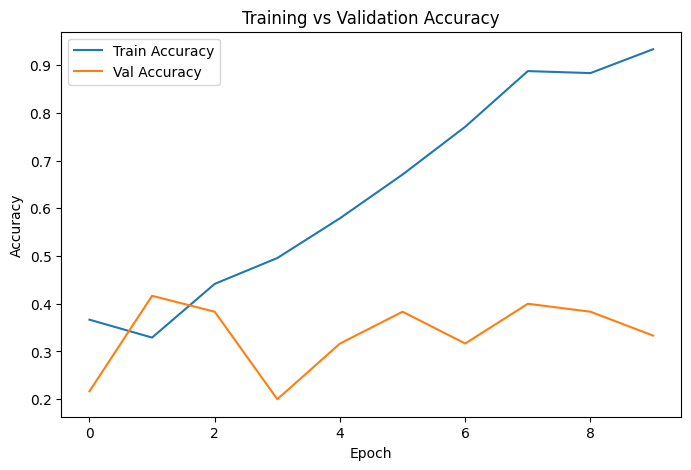

Severity classifier saved as severity_classifier.h5


'\n- Which severity class is hardest to learn?\n  → Moderate (overlaps visually with minor & severe)\n\n- Why is severity a subjective label?\n  → Severity depends on human judgment, repair cost, and context\n'

In [53]:
# ==========================================
# Week 5 – Damage Severity Classification
# Objective: Train a CNN to classify damage severity
# ==========================================

# -------------------------------
# Step 1: Imports
# -------------------------------
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import os

# -------------------------------
# Step 2: Load Dataset
# Dataset structure:
# cropped_damage/
# ├── minor/
# ├── moderate/
# └── severe/
# -------------------------------

DATASET_PATH = "cropped_damage"
IMG_SIZE = (128, 128)
BATCH_SIZE = 32
SEED = 42

train_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names
print("Classes:", class_names)

# Normalize images
normalization_layer = layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))

# -------------------------------
# Step 3: Build CNN Model
# -------------------------------
model = models.Sequential([
    layers.Conv2D(32, 3, activation="relu", input_shape=(128, 128, 3)),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, activation="relu"),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dense(3, activation="softmax")  # minor / moderate / severe
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

# -------------------------------
# Step 4: Train Model
# -------------------------------
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

# -------------------------------
# Step 5: Evaluation
# -------------------------------
plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Training vs Validation Accuracy")
plt.show()

# -------------------------------
# Step 6: Save Model
# -------------------------------
model.save("severity_classifier.h5")
print("Severity classifier saved as severity_classifier.h5")

# -------------------------------
# Reflection
# -------------------------------
"""
- Which severity class is hardest to learn?
  → Moderate (overlaps visually with minor & severe)

- Why is severity a subjective label?
  → Severity depends on human judgment, repair cost, and context
"""


✅ Models loaded successfully

0: 480x640 1 be_den, 1 tray_son, 300.8ms
Speed: 9.3ms preprocess, 300.8ms inference, 8.2ms postprocess per image at shape (1, 3, 480, 640)
Detected 2 damage regions


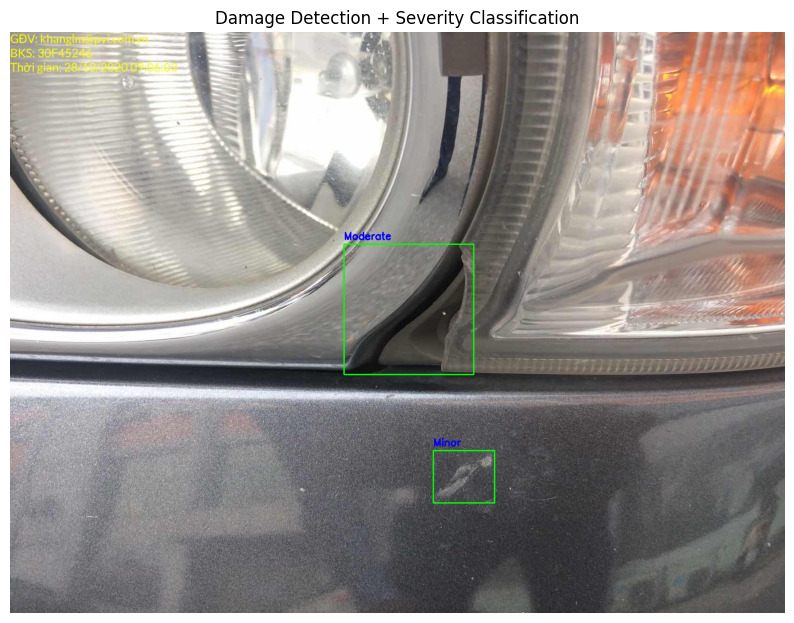


Reflection:
- Detection errors propagate to severity classification.
- Modular design allows improving detector or classifier independently.
- Pipeline demonstrates feasibility of automated damage assessment.



In [56]:
# =====================================================
# Week 5 – End-to-End Vehicle Damage Severity Pipeline
# Objective: Integrate YOLOv8 detection + severity classification
# =====================================================

# -------------------------------
# Step 1: Imports
# -------------------------------
import cv2
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO
import tensorflow as tf
import os

# -------------------------------
# Step 2: Load Models
# -------------------------------

# Path to trained YOLOv8 model
YOLO_MODEL_PATH = "/content/best (1).pt"

# Path to trained severity classifier
SEVERITY_MODEL_PATH = "severity_classifier.h5"

assert os.path.exists(YOLO_MODEL_PATH), "YOLO model not found"
assert os.path.exists(SEVERITY_MODEL_PATH), "Severity model not found"

yolo_model = YOLO(YOLO_MODEL_PATH)
severity_model = tf.keras.models.load_model(SEVERITY_MODEL_PATH)

print("✅ Models loaded successfully")

# -------------------------------
# Step 3: Load Image
# -------------------------------
# Use an image from the previously loaded dataset for testing
# INPUT_DIR is defined as '/kaggle/input/vehide-dataset-automatic-vehicle-damage-detection/image/image'

# Select the first image from INPUT_DIR for testing
IMAGE_PATH = os.path.join(INPUT_DIR, os.listdir(INPUT_DIR)[0])
assert os.path.exists(IMAGE_PATH), "Test image not found"

image = cv2.imread(IMAGE_PATH)
orig_image = image.copy()

# -------------------------------
# Step 4: YOLOv8 Inference
# -------------------------------
results = yolo_model(image, conf=0.25)

boxes = []
for r in results:
    for box in r.boxes:
        x1, y1, x2, y2 = map(int, box.xyxy[0])
        boxes.append((x1, y1, x2, y2))

print(f"Detected {len(boxes)} damage regions")

# -------------------------------
# Step 5: Predict Severity
# -------------------------------
severity_labels = ["Minor", "Moderate", "Severe"]
IMG_SIZE = (128, 128)

for (x1, y1, x2, y2) in boxes:
    crop = orig_image[y1:y2, x1:x2]

    if crop.size == 0:
        continue

    crop_resized = cv2.resize(crop, IMG_SIZE)
    crop_resized = crop_resized / 255.0
    crop_resized = np.expand_dims(crop_resized, axis=0)

    preds = severity_model.predict(crop_resized, verbose=0)
    severity_idx = np.argmax(preds)
    severity = severity_labels[severity_idx]

    # Draw bounding box and label
    cv2.rectangle(orig_image, (x1, y1), (x2, y2), (0, 255, 0), 2)
    cv2.putText(
        orig_image,
        severity,
        (x1, y1 - 10),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.7,
        (255, 0, 0),
        2
    )

# -------------------------------
# Step 6: Visualization
# -------------------------------
plt.figure(figsize=(10, 8))
plt.imshow(cv2.cvtColor(orig_image, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("Damage Detection + Severity Classification")
plt.show()

# -------------------------------
# Reflection (for report)
# -------------------------------
print("""
Reflection:
- Detection errors propagate to severity classification.
- Modular design allows improving detector or classifier independently.
- Pipeline demonstrates feasibility of automated damage assessment.
""")